In [1]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [22]:
# 2. Load Dataset
df = pd.read_csv("C:\\Users\\vsri9\\OneDrive\\Desktop\\sales_performance_analysis\\Sales_Analysis_Cleaned.csv")
df.head()


,Order ID,Order Date,Ship Date,Customer Name,Segment,State,Region,Product Name,Category,Sales,Quantity,Discount,Profit,Shipping Days
0,Ve-6459-774494,2024-03-01 00:00:00,2025-03-16 00:00:00,Raymond Hodges,Corporate,California,East,Pen Set,Storage,647.92,8,0.3,114.55,380
1,Yt-0688-736606,2024-03-30 00:00:00,2024-12-23 00:00:00,Michael West,Corporate,Illinois,Central,Office Chair,Furniture,410.73,2,0.0,450.61,268
2,rz-4962-318636,2024-01-04 00:00:00,2024-12-29 00:00:00,Rebecca Stewart,Corporate,Illinois,West,Desk Lamp,Storage,546.59,5,0.3,-16.59,360
3,KF-6615-807782,2024-03-16 00:00:00,2024-05-08 00:00:00,Melvin Huffman,Consumer,Texas,South,Whiteboard,Stationery,519.77,8,0.0,194.32,53
4,ph-8214-271190,2024-02-29 00:00:00,2025-04-30 00:00:00,Ian Gibson,Consumer,Michigan,Central,Desk Lamp,Storage,202.59,9,0.3,105.66,426


In [25]:
df.describe()

,Sales,Quantity,Discount,Profit,Shipping Days
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,486.447867,5.580000,0.154000,170.080400,286.986667
std,275.372749,2.871452,0.114476,188.041926,159.656636
min,20.130000,1.000000,0.000000,-198.710000,0.000000
25%,242.842500,3.000000,0.100000,16.892500,145.750000
50%,515.395000,5.000000,0.100000,188.900000,285.500000
75%,743.745000,8.000000,0.300000,315.492500,389.250000
max,991.700000,10.000000,0.300000,492.430000,668.000000


In [23]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Customer Name    0
Segment          0
State            0
Region           0
Product Name     0
Category         0
Sales            0
Quantity         0
Discount         0
Profit           0
Shipping Days    0
dtype: int64

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       150 non-null    object 
 1   Order Date     150 non-null    object 
 2   Ship Date      150 non-null    object 
 3   Customer Name  150 non-null    object 
 4   Segment        150 non-null    object 
 5   State          150 non-null    object 
 6   Region         150 non-null    object 
 7   Product Name   150 non-null    object 
 8   Category       150 non-null    object 
 9   Sales          150 non-null    float64
 10  Quantity       150 non-null    int64  
 11  Discount       150 non-null    float64
 12  Profit         150 non-null    float64
 13  Shipping Days  150 non-null    int64  
dtypes: float64(3), int64(2), object(9)
memory usage: 16.5+ KB


In [6]:
# 3. Data Cleaning
df.drop_duplicates(inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df[['Order Date', 'Ship Date', 'Shipping Days']].head()



,Order Date,Ship Date,Shipping Days
0,2024-03-01,2025-03-16,380
1,2024-03-30,2024-12-23,268
2,2024-01-04,2024-12-29,360
3,2024-03-16,2024-05-08,53
4,2024-02-29,2025-04-30,426


In [8]:
# 4. Encoding Categorical Columns
le = LabelEncoder()
df['Segment'] = le.fit_transform(df['Segment'])
df['State'] = le.fit_transform(df['State'])
df['Region'] = le.fit_transform(df['Region'])
df['Category'] = le.fit_transform(df['Category'])
# Show the first 5 rows of the encoded columns
df[['Segment', 'State', 'Region', 'Category']].head()

,Segment,State,Region,Category
0,1,0,1,3
1,1,3,0,1
2,1,3,3,3
3,0,7,2,2
4,0,4,0,3


In [10]:
# 5. Feature Scaling
scaler = StandardScaler()
df[['Sales', 'Quantity', 'Discount', 'Shipping Days']] = scaler.fit_transform(df[['Sales', 'Quantity', 'Discount', 'Shipping Days']])
# Show the output
df[['Sales', 'Quantity', 'Discount', 'Shipping Days']].head()

,Sales,Quantity,Discount,Shipping Days
0,0.588341,0.845603,1.279652,0.584535
1,-0.275886,-1.250933,-1.349770,-0.119320
2,0.219134,-0.202665,1.279652,0.458847
3,0.121413,0.845603,-1.349770,-1.470472
4,-1.034267,1.195025,1.279652,0.873619


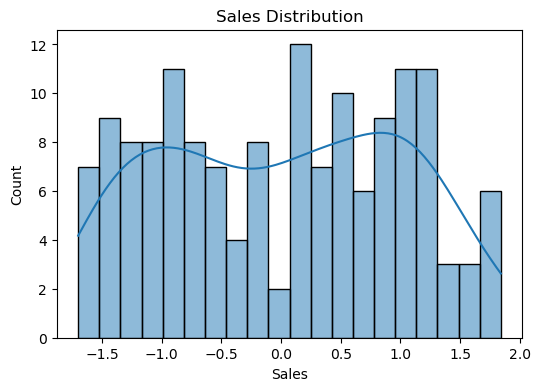

In [19]:
# ---------------------- Visualizations ----------------------
#Sales distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Sales'], bins=20, kde=True)
plt.title('Sales Distribution')
plt.show()


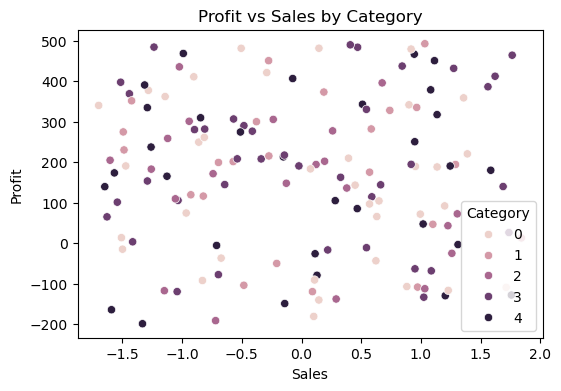

In [11]:
#Profit vs Sales by Category
plt.figure(figsize=(6,4))
sns.scatterplot(x='Sales', y='Profit', hue='Category', data=df)
plt.title('Profit vs Sales by Category')
plt.show()

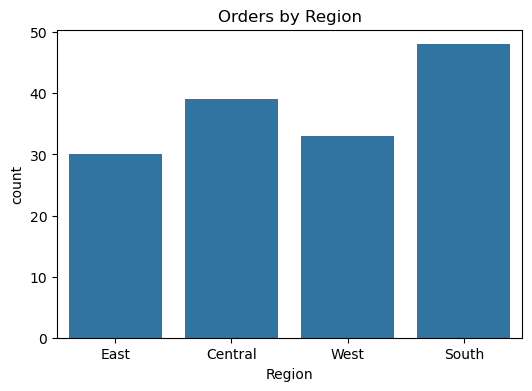

In [27]:
#Orders by region
plt.figure(figsize=(6,4))
sns.countplot(x='Region', data=df)
plt.title('Orders by Region')
plt.show()


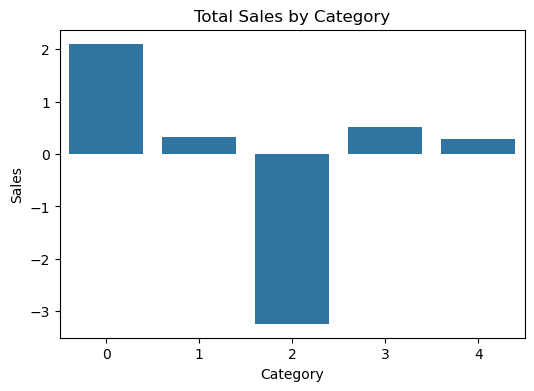

In [13]:
#Total sales by category
plt.figure(figsize=(6,4))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum, errorbar=None)
plt.title('Total Sales by Category')
plt.show()

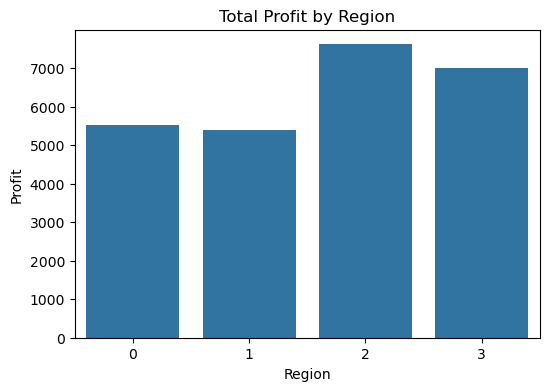

In [14]:
#Total Profit by Region
plt.figure(figsize=(6,4))
sns.barplot(x='Region', y='Profit', data=df, estimator=sum, errorbar=None)
plt.title('Total Profit by Region')
plt.show()

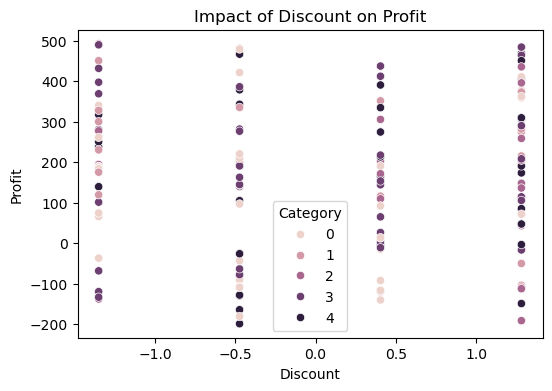

In [15]:
#Impact of Discount on Profit
plt.figure(figsize=(6,4))
sns.scatterplot(x='Discount', y='Profit', hue='Category', data=df)
plt.title('Impact of Discount on Profit')
plt.show()

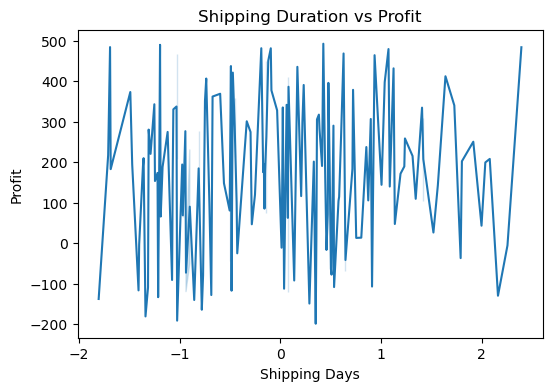

In [16]:
#Shipping Duration vs Profit
plt.figure(figsize=(6,4))
sns.lineplot(x='Shipping Days', y='Profit', data=df)
plt.title('Shipping Duration vs Profit')
plt.show()

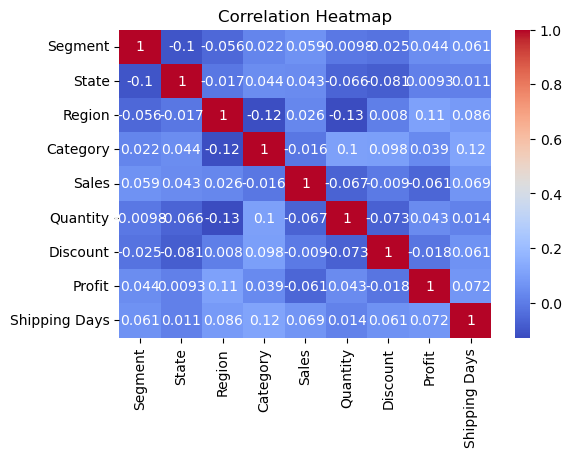

In [17]:
#Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [18]:
print("\n✅ Project Completed Successfully with  Visualizations")



✅ Project Completed Successfully with  Visualizations
